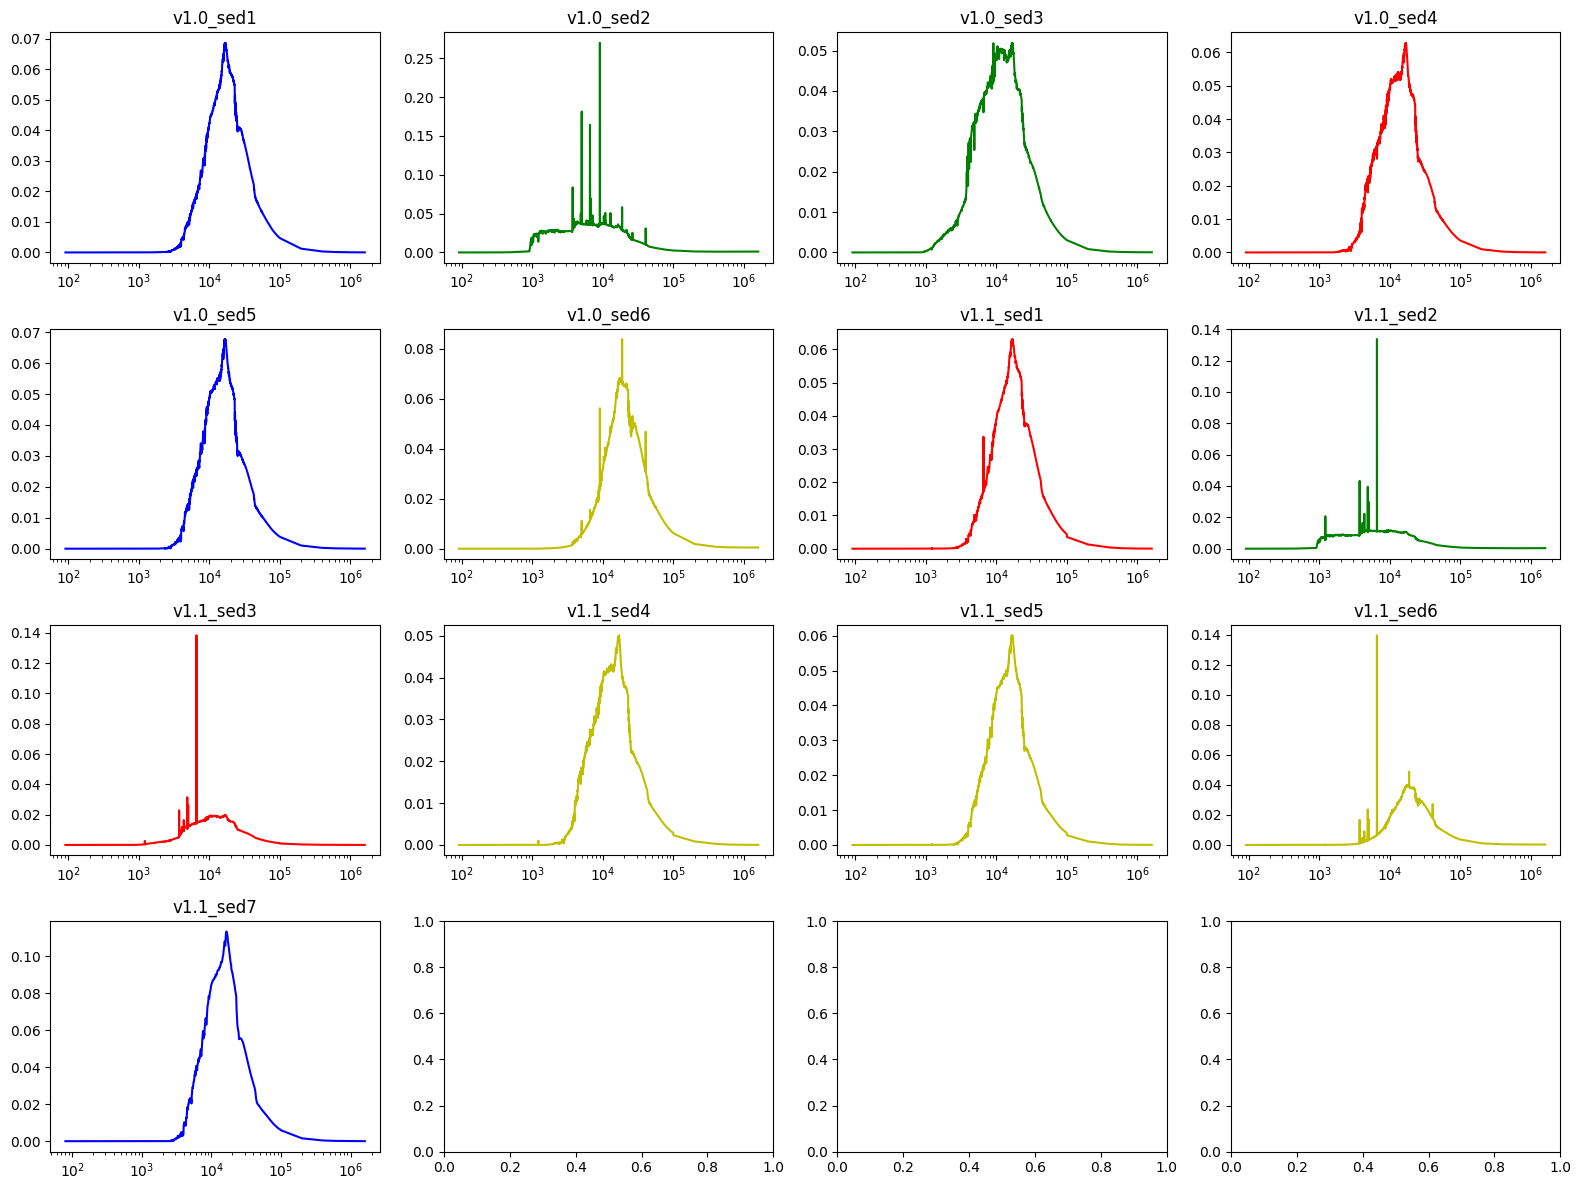

In [2]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
f=glob('eazy*')
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
p=['r','b','g','y']
wave1={}
norm_flux1={}
for idx, i in enumerate(f):
    wave, flux = np.loadtxt(i, unpack=True)
    flux *= wave**2. / 3e18
    norm=np.sqrt(np.sum(flux**2))
    norm_flux=flux/norm
    wave1[i]=wave
    norm_flux1[i]=norm_flux
    ax = axes[idx]
    ax.plot(wave, norm_flux,color=np.random.choice(p))
    ax.set_title(i[-13:-4])
    #ax.set_xlim(0,20000)
    ax.set_xscale('log')




plt.tight_layout()
plt.show()


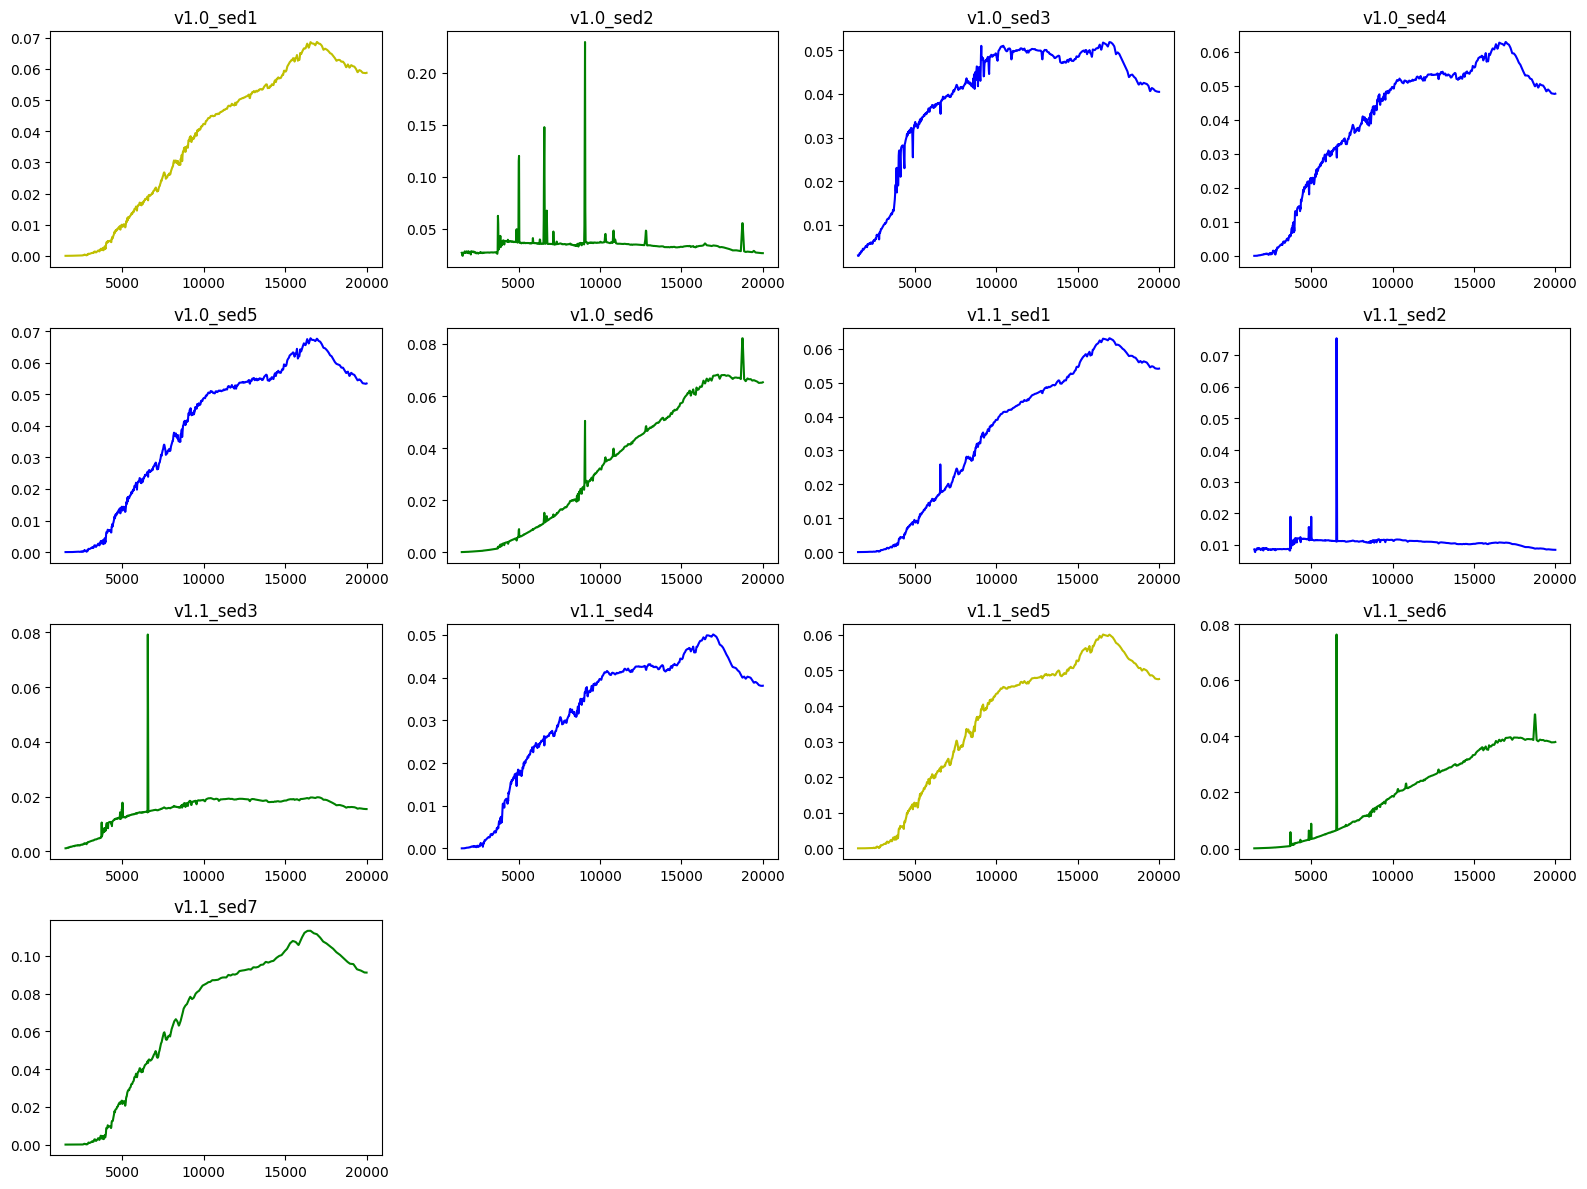

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
p=['r','b','g','y']
wave_grid = np.linspace(1500, 20000, 1000)
norm_flux_interp={}
for idx, i in enumerate(wave1.keys()):
    norm_flux_int = np.interp(wave_grid, wave1[i], norm_flux1[i])
    norm_flux_interp[i]=norm_flux_int
    ax = axes[idx]
    ax.plot(wave_grid, norm_flux_int,color=np.random.choice(p))
    ax.set_title(i[-13:-4])
    #ax.set_xscale('log')

for idx in range(len(f), len(axes)):
    axes[idx].axis('off')


plt.tight_layout()
plt.show()

In [4]:
flux_list = []
for name in norm_flux_interp.keys():
    flux_list.append(norm_flux_interp[name])

data_matrix = np.array(flux_list)

In [5]:
from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(data_matrix)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


## Verification

In [6]:
import pickle
with open("best_gmm_model.pkl", "rb") as f:
    best_model = pickle.load(f)


In [7]:
mean_prior=[ 1.29110220e-08,-6.97051883e-09  ,4.21906659e-08 ,-1.06249881e-08]
cov_prior= [[ 0.00224612 , 0.00277605 ,-0.00087143 ,-0.00754739],
 [ 0.00282488 , 0.0473652 , -0.0984635 ,  0.0235586 ],
 [-0.00097773 ,-0.09822968 , 0.27608311 ,-0.12904539],
 [-0.00751953,  0.02336181, -0.12875907 , 0.11026364]]

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sedpy.observate import load_filters, getSED
from sklearn.mixture import GaussianMixture

# --- 1. Sample from your GMM in coefficient space ---
def sample_coeffs_from_gmm_XD(mean, cov, n_samples, random_state=0):
    rng = np.random.default_rng(random_state)
    return rng.multivariate_normal(mean, cov, size=n_samples)

# --- 2. Rebuild SEDs from coefficients ---
def rebuild_seds(coeffs, components):
    return coeffs @ components  # matrix multiply

# --- 3. Project SEDs into photometry ---
def seds_to_photometry(seds, wavelengths, filter_names):
    filters = load_filters(filter_names)
    phot = np.array([getSED(wavelengths, s, filters) for s in seds])
    return phot



# Step 1: sample from GMM
c_sim = sample_coeffs_from_gmm_XD(mean_prior, cov_prior, n_samples=100000)

# Step 2: rebuild synthetic SEDs
seds_sim = rebuild_seds(c_sim, H)

# Step 3: project to photometry
filter_names = ['hsc_g','hsc_r','hsc_i']  # replace with COSMOS/HSC bands you use
phot_sim_XD = seds_to_photometry(seds_sim, wave_grid, filter_names)



C:\Users\pranav\AppData\Local\Temp\ipykernel_29628\1153117233.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return rng.multivariate_normal(mean, cov, size=n_samples)
C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sedpy.observate import load_filters, getSED
from sklearn.mixture import GaussianMixture
import joblib

# --- 1. Sample from your GMM in coefficient space ---
def sample_coeffs_from_gmm(gmm, scaler,n_samples, random_state=0):
    """Draw samples of PCA/NMF coefficients from fitted GMM."""
    c_sim, _ = gmm.sample(n_samples)
    c=scaler.inverse_transform(c_sim)
    return c

# --- 2. Rebuild SEDs from coefficients ---
def rebuild_seds(coeffs, components):
    return coeffs @ components  # matrix multiply

# --- 3. Project SEDs into photometry ---
def seds_to_photometry(seds, wavelengths, filter_names):
    filters = load_filters(filter_names)
    phot = np.array([getSED(wavelengths, s, filters) for s in seds])
    return phot
scaler = joblib.load("scaler.pkl")
# Step 1: sample from GMM
c_sim = sample_coeffs_from_gmm(best_model,scaler, n_samples=100000)

# Step 2: rebuild synthetic SEDs
seds_sim = rebuild_seds(c_sim, H)

# Step 3: project to photometry
filter_names = ['hsc_g','hsc_r','hsc_i']  # replace with COSMOS/HSC bands you use
phot_sim_LS = seds_to_photometry(seds_sim, wave_grid, filter_names)



C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


In [10]:
phot_sim_XD

array([[         nan,          nan,          nan],
       [-15.22367313, -14.54826373,          nan],
       [         nan,          nan, -15.82932625],
       ...,
       [-17.38348548, -17.28534548, -14.64868198],
       [-17.16737068, -17.21279652, -16.61115811],
       [         nan,          nan,          nan]])